In [60]:
import pandas as pd
import matplotlib.pyplot as plt

#importing the 2025 csv ttc subway delay data as a pandas dataframe
#df_2025 = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/raw/csv/ttc-subway-delay-data-2025.csv')
df = pd.read_csv('C:/Users/safab/ML7-Project/C8ML7_subwaydelay/data/processed/ttc_subway_delay_data_obt.csv')

#Adding a new column that is a formatted Year Column into data type Date rather than a string
df['Formatted Date'] = pd.to_datetime(df['date'])

#Extracted Year, Month, and Day from Date
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day of the Month'] = df['Formatted Date'].dt.day

#Formatted time from string to time and extracting hour of day
df['Formatted Time'] = pd.to_datetime(df['time'], format='%H:%M').dt.time
df['Hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour 

#dropped preformatted columns, as well columns that are not used such as id and Bound
columns_to_drop = ['date', 'time', 'bound']

df = df.drop(columns=columns_to_drop)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24389 entries, 0 to 24388
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   day                 24389 non-null  str           
 1   station             24389 non-null  str           
 2   code                24389 non-null  str           
 3   delayed_minutes     24389 non-null  int64         
 4   gap_minutes         24389 non-null  int64         
 5   line                24388 non-null  str           
 6   vehicle             24389 non-null  int64         
 7   year                24389 non-null  int64         
 8   datetime            24389 non-null  str           
 9   hour                24389 non-null  int64         
 10  weekday             24389 non-null  int64         
 11  is_weekend          24389 non-null  int64         
 12  month               24389 non-null  int64         
 13  week                24389 non-null  int64         
 14  p

In [ ]:
df

Minute Delay Averge (grouped by month): Month
1     5.596738
2     5.513514
3     5.628980
4     5.713718
5     5.735776
6     5.617775
7     5.499726
8     5.489216
9     5.444682
10    5.474687
11    5.327116
12    5.554940
Name: delayed_minutes, dtype: float64



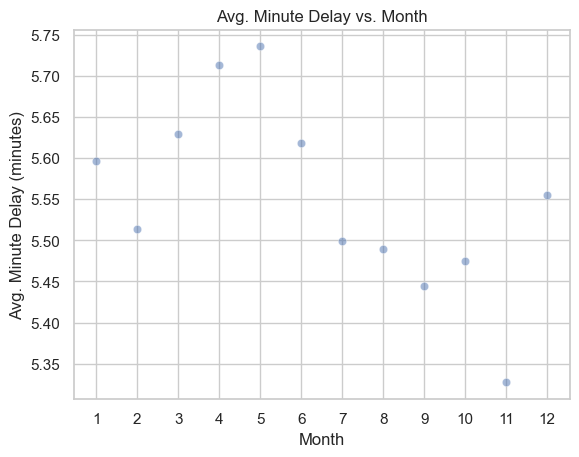

In [62]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per month in 2025 and plot the results

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")


monthly_avg_groupby = df.groupby(df['Month'])['delayed_minutes'].mean()

print(f"Minute Delay Averge (grouped by month): {df.groupby(df['Month'])['delayed_minutes'].mean()}\n")


#Plotting Average Delay Time vs Month with raw uneditted data
plt.xlabel('Month')
plt.ylabel('Avg. Minute Delay (minutes)')
plt.xticks(df['Month'].unique())
plt.title('Avg. Minute Delay vs. Month')
#plt.scatter((df_2025['Month'].unique()), daily_avg_groupby, s=5)
sns.scatterplot(x=df['Month'].unique(), y=monthly_avg_groupby, alpha=0.5)

plt.show()


Min Delay Averge (grouped by Day of week): <StringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Length: 7, dtype: str


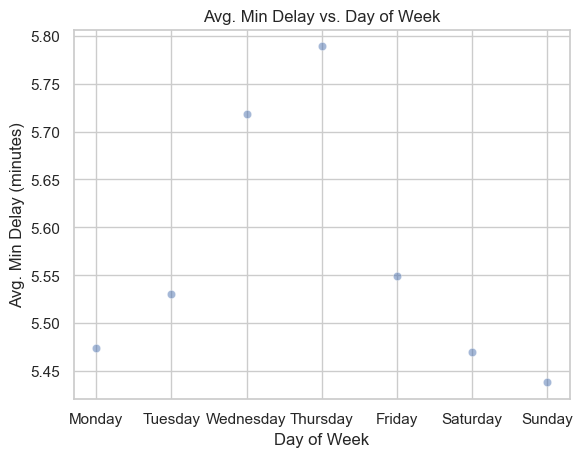

In [63]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

dayofweek_avg_groupby = df.groupby(df['day'])['delayed_minutes'].mean()
print(f"Min Delay Averge (grouped by Day of week): {df['day'].unique()}")

# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df['day'].unique(), y=dayofweek_avg_groupby, alpha=0.5)
plt.xlabel('Day of Week')
plt.ylabel('Avg. Min Delay (minutes)')
plt.title('Avg. Min Delay vs. Day of Week')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

[2024 2025 2023]


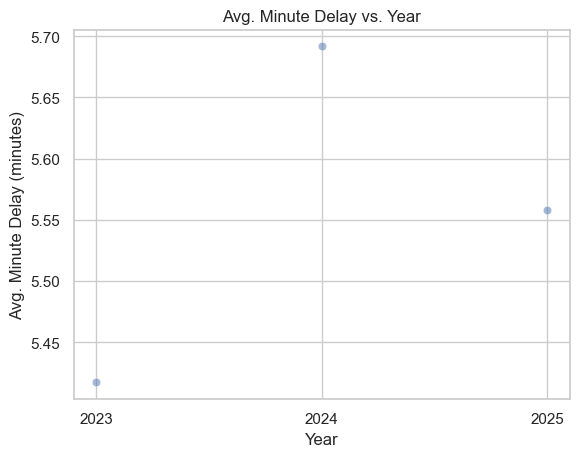

In [64]:
import seaborn as sns

# This code will aim to try and calculate the average min delay per day of the week in 2025

year_avg_groupby = df.groupby(df['Year'])['delayed_minutes'].mean()
#print(f"Min Delay Averge (grouped by Day of week): {df_2025['Day'].unique()}")
print(df['year'].unique())
# Set a clean visual style for plot using seaborn instead of .scatter from matplotlib
sns.set_theme(style="whitegrid")

#Plotting Average Delay Time vs Month with raw uneditted data
sns.scatterplot(x=df['year'].unique(), y=year_avg_groupby, alpha=0.5)
plt.xlabel('Year')
plt.xticks([2023,2024,2025])
plt.ylabel('Avg. Minute Delay (minutes)')
plt.title('Avg. Minute Delay vs. Year')
#plt.scatter((df_2025['Day'].unique()), dayofweek_avg_groupby, s=7)
#plt.grid(True)
plt.show()

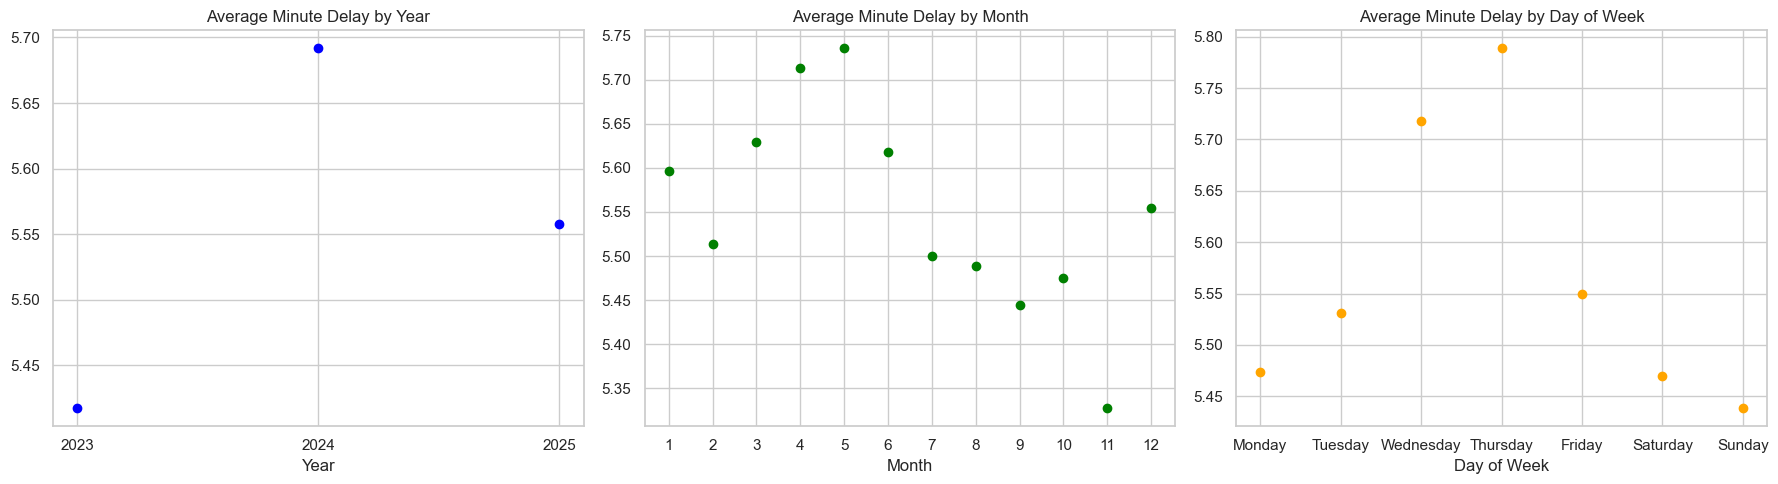

In [67]:
#Combining all three plots of Avg. Minute Delay per Day of week, month, and year in one fig. 

#A list of the y values for the plots (delayed minutes grouped by respective feature)
year_avg_groupby = df.groupby(df['year'])['delayed_minutes'].mean()
monthly_avg_groupby = df.groupby(df['month'])['delayed_minutes'].mean()
dayofweek_avg_groupby = df.groupby(df['day'])['delayed_minutes'].mean()

#Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Average Minute Delay by Year
axes[0].scatter(df['year'].unique(), year_avg_groupby, color='blue')
axes[0].set_xlabel("Year")
axes[0].set_xticks([2023,2024,2025])
axes[0].set_title("Average Minute Delay by Year")

# Average Minute Delay by Month
axes[1].scatter(df['month'].unique(), monthly_avg_groupby, color='green')
axes[1].set_xlabel("Month")
axes[1].set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
axes[1].set_title("Average Minute Delay by Month")

# Average Minute Delay by Day of Week
axes[2].scatter(df['day'].unique(),dayofweek_avg_groupby, color='orange')
axes[2].set_xlabel("Day of Week")
axes[2].set_title("Average Minute Delay by Day of Week")


# Save before showing
plt.tight_layout()
plt.savefig("avg_minute_day_per_time.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show

In [ ]:
#This code aims to showcase the top5 stations with the highest tot+

# Filter only rows with actual delays
delays_df = df[df["delayed_minutes"] > 0].copy()
#delays_df = df

# Group by station and calculate delay metrics
station_delay_summary = delays_df.groupby("mapped_station").agg(
    Total_Incidents=("delayed_minutes", "count"),
    Total_Min_Delay=("delayed_minutes", "sum"),
    Avg_Delay_Per_Incident=("delayed_minutes", "mean")
).sort_values(by="Total_Incidents", ascending=False)

#Round average delay
station_delay_summary["Avg_Delay_Per_Incident"] = station_delay_summary["Avg_Delay_Per_Incident"].round(2)

#Display top 5 stations with most delay incidents
station_delay_summary.head(5)

,Total_Incidents,Total_Min_Delay,Avg_Delay_Per_Incident
mapped_station,,,
Sheppard–Yonge,1085,5867,5.41
Eglinton,1082,6078,5.62
Kennedy,994,4770,4.80
Kipling,963,4537,4.71
Finch,858,4072,4.75


Available station names (sample): ['Sheppard–Yonge', 'Eglinton', 'Kennedy', 'Kipling', 'Finch', 'St. George', 'Bloor–Yonge', 'Wilson', 'Dundas West', 'Davisville']


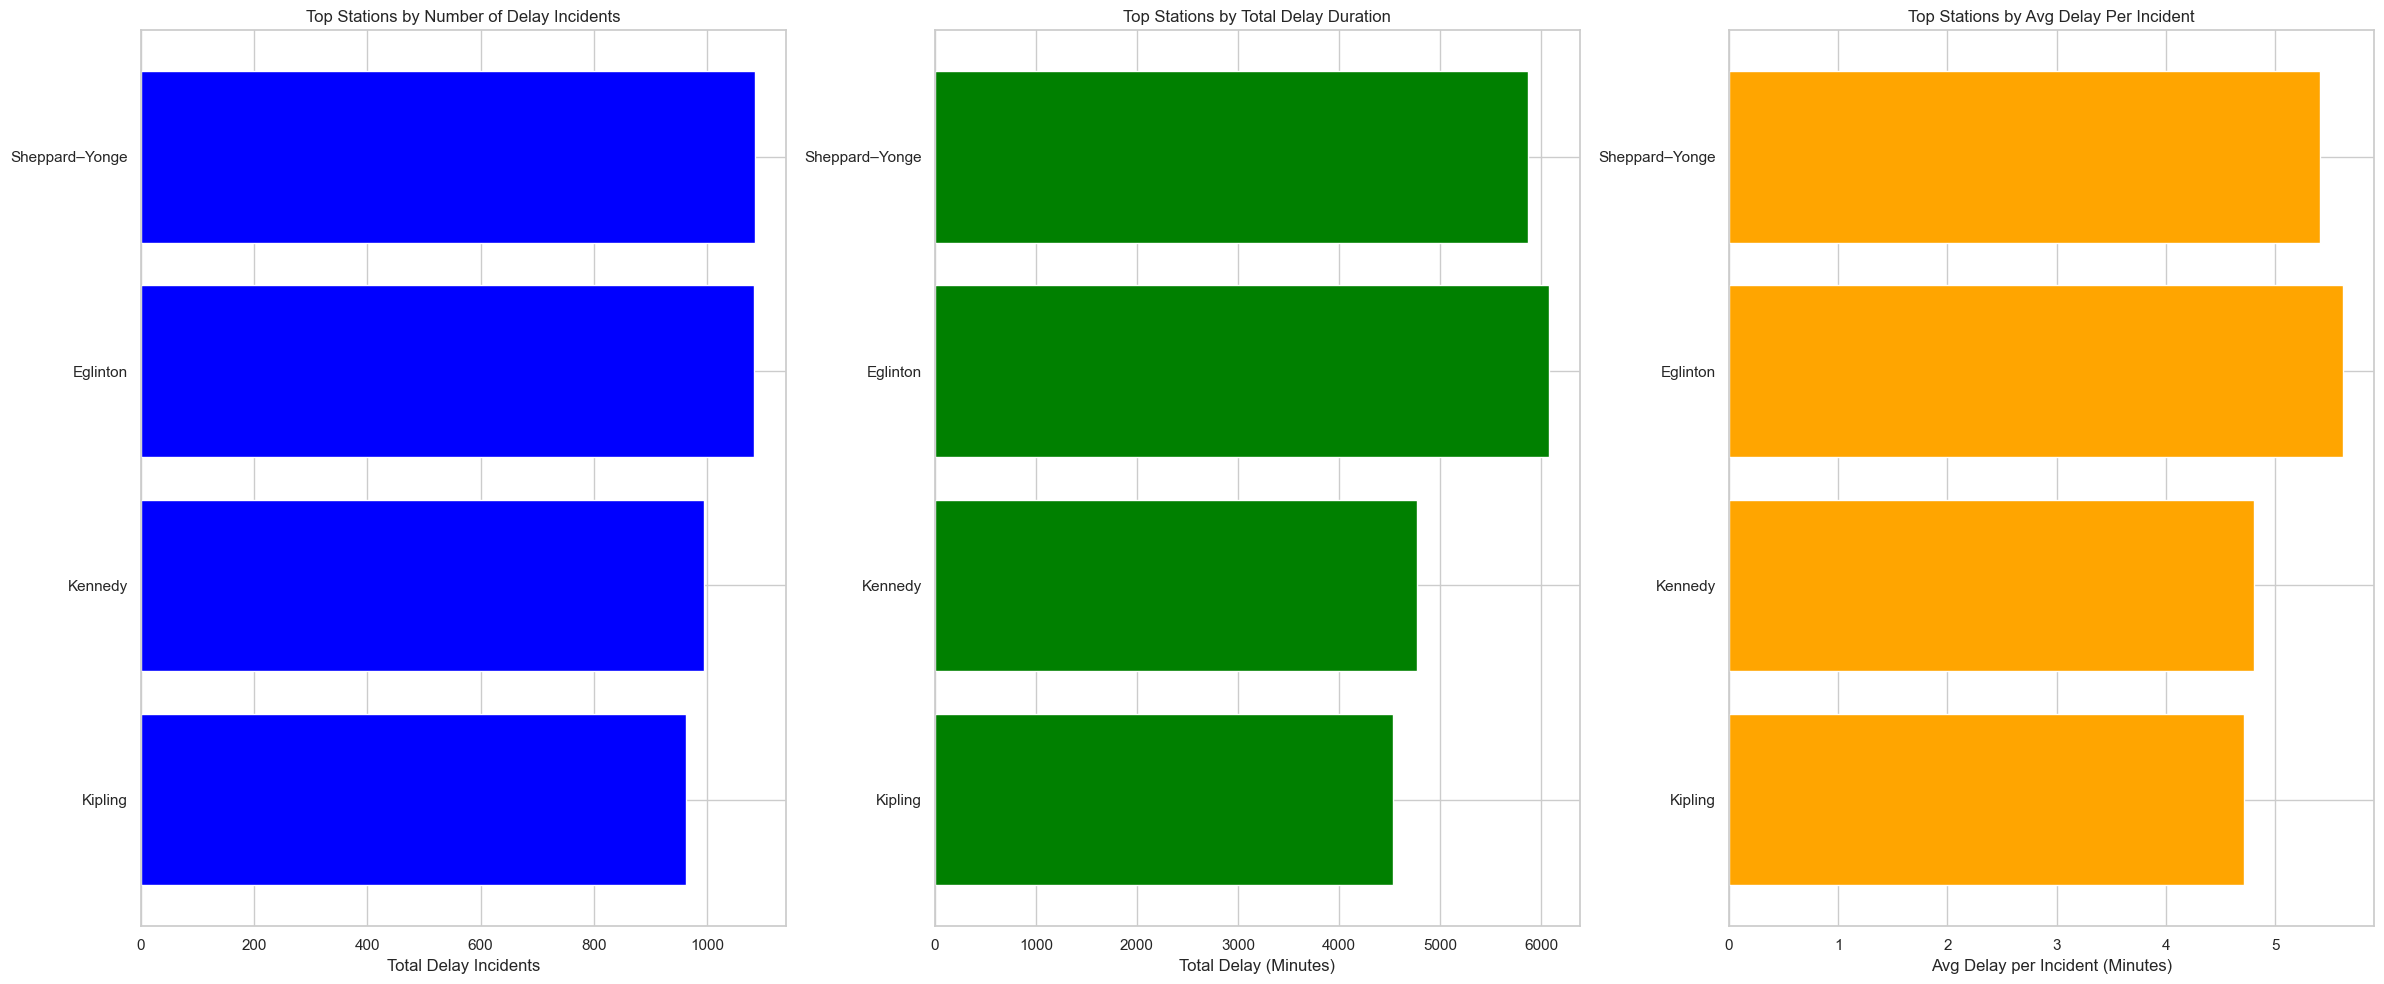

In [ ]:
# Step 1: Get top 5 stations by Total_Incidents
top_stations = station_delay_summary.sort_values(by="Total_Incidents", ascending=False).head(4)

print("Available station names (sample):", station_delay_summary.index.tolist()[:10])  # See what's in the index

# Step 4: Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
stations_reversed = top_stations.index[::-1]

# Total Incidents
axes[0].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Incidents"], color='blue')
axes[0].set_xlabel("Total Delay Incidents")
axes[0].set_title("Top Stations by Number of Delay Incidents")

# Total Delay
axes[1].barh(stations_reversed, top_stations.loc[stations_reversed]["Total_Min_Delay"], color='green')
axes[1].set_xlabel("Total Delay (Minutes)")
axes[1].set_title("Top Stations by Total Delay Duration")

# Avg Delay
axes[2].barh(stations_reversed, top_stations.loc[stations_reversed]["Avg_Delay_Per_Incident"], color='orange')
axes[2].set_xlabel("Avg Delay per Incident (Minutes)")
axes[2].set_title("Top Stations by Avg Delay Per Incident")


# Save before showing
plt.tight_layout()
plt.savefig("top_stations_with_delays.png", dpi=300, bbox_inches='tight')  # Save first
plt.show()  # Then show

This project explores and analyzes 2025 TTC subway delay data using Python. The goal is to uncover patterns in subway delays across:

 Months
 Days of the Week
 Yearly averages
Stations with the highest delay incidents

Through data grouping, aggregation, and visualization, this analysis provides insights into delay trends and high-impact locations within the Toronto subway system. We used various Python libraries such as Pandas for Data manipulation and aggregation as well as matplotlib and seaborn for data visualization and statistical plotting. The TTC delay data was loaded into a Pandas DataFrame for ease of analysis. A table below showcases the fields of the dataset:

TABLE HERE

For data exploration, we plotted the average delay by month, year and day of the week. These plots are shown below. 

PLOT HERE

SUMMARY ON FINDINGS OF PLOTS HERE

**Key Insights (Expected Outcomes)**

Certain months likely show higher delay averages (e.g., winter months).

Weekday vs weekend delay trends may differ.

A small number of stations likely contribute disproportionately to incidents.

Total incidents and total delay minutes help distinguish between:

Frequent minor delays

Fewer but severe delays